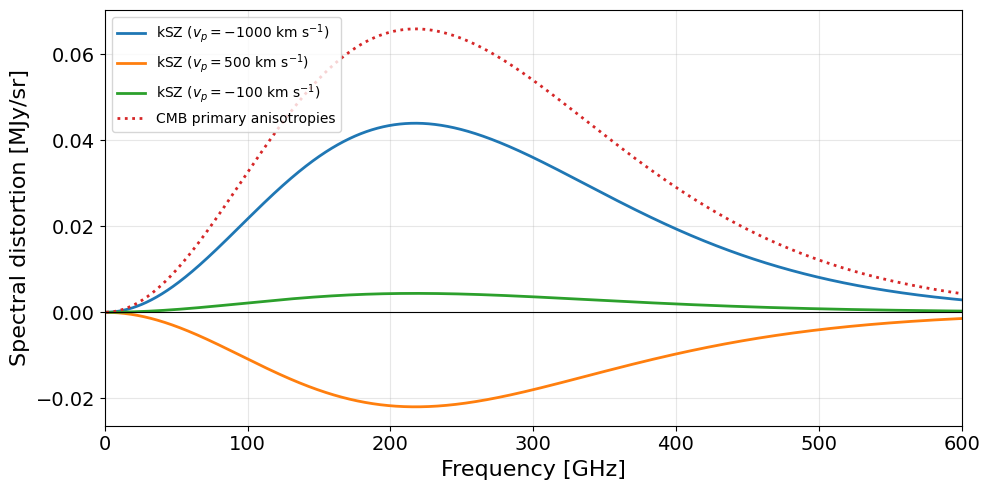

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI)
h = 6.62607015e-34      # Planck constant [J s]
kB = 1.380649e-23       # Boltzmann constant [J K^-1]
c = 2.99792458e8        # Speed of light [m s^-1]
T_CMB = 2.7255          # CMB temperature [K]

# Frequency grid in GHz
nu_ghz = np.linspace(1.0, 600.0, 2000)       # [GHz]
nu = nu_ghz * 1e9                             # [Hz]

# Dimensionless frequency x = h nu / (kB T_CMB)
x = h * nu / (kB * T_CMB)

# Prefactor I0 in MJy/sr
I0_SI = 2.0 * (kB * T_CMB) ** 3 / (h ** 2 * c ** 2)   # [W m^-2 Hz^-1 sr^-1]
jy_to_SI = 1e-26                                      # 1 Jy = 1e-26 W m^-2 Hz^-1
I0 = I0_SI / jy_to_SI / 1e6                           # [MJy sr^-1]

def g_tsz(x):
    """Spectral shape for thermal SZ in the non relativistic limit."""
    ex = np.exp(x)
    return x**4 * ex / (ex - 1.0)**2 * (x * (ex + 1.0) / (ex - 1.0) - 4.0)

def h_ksz(x):
    """Spectral shape for kinetic SZ and primary CMB anisotropies."""
    ex = np.exp(x)
    return x**4 * ex / (ex - 1.0)**2

# Compton y parameters for tSZ curves
y_vals = [5.0e-5, 1.0e-4]

# Optical depth and peculiar velocities for kSZ
tau_e = 1.0e-2                            # typical cluster optical depth
v_ksz = np.array([-1000.0, 500.0, -100.0]) * 1e3   # [m s^-1]
beta_ksz = v_ksz / c                      # v/c

# Primary CMB anisotropy amplitude (DeltaT/T)
deltaT_over_T = 5.0e-5                    # adjust to taste

# Compute tSZ curves
deltaI_tsz = [I0 * y * g_tsz(x) for y in y_vals]

# Compute kSZ curves
deltaI_ksz = []
for beta in beta_ksz:
    y_ksz = tau_e * beta                  # effective "y_kSZ"
    deltaI_ksz.append(-I0 * y_ksz * h_ksz(x))

# Primary CMB anisotropy intensity curve
deltaI_cmb = I0 * deltaT_over_T * h_ksz(x)

# -------------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# tSZ (dashed blue)
# ax.plot(nu_ghz, deltaI_tsz[0], linestyle="--", linewidth=1.5,
#         label=r"tSZ ($y = 5.0 \times 10^{-5}$)")
# ax.plot(nu_ghz, deltaI_tsz[1], linestyle="--", linewidth=2.0,
#         label=r"tSZ ($y = 1.0 \times 10^{-4}$)")

# kSZ (solid green)
labels_ksz = [r"kSZ ($v_p = -1000$ km s$^{-1}$)",
              r"kSZ ($v_p = 500$ km s$^{-1}$)",
              r"kSZ ($v_p = -100$ km s$^{-1}$)"]
for di, lab in zip(deltaI_ksz, labels_ksz):
    ax.plot(nu_ghz, di, linewidth=2.0, label=lab)

# Primary CMB anisotropies (dotted red)
ax.plot(nu_ghz, deltaI_cmb,
        linestyle=":", linewidth=2.0,
        label=r"CMB primary anisotropies")

ax.axhline(0.0, color="k", linewidth=0.8)
ax.set_xlim(0.0, 600.0)

# Bigger axis labels
ax.set_xlabel("Frequency [GHz]", fontsize=16)
ax.set_ylabel(r"Spectral distortion [MJy/sr]", fontsize=16)

# Bigger tick labels
ax.tick_params(axis="both", which="major", labelsize=14)

ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.savefig("plots_thesis/ksz_intensity_presention.png", dpi=300, bbox_inches="tight")
plt.show()


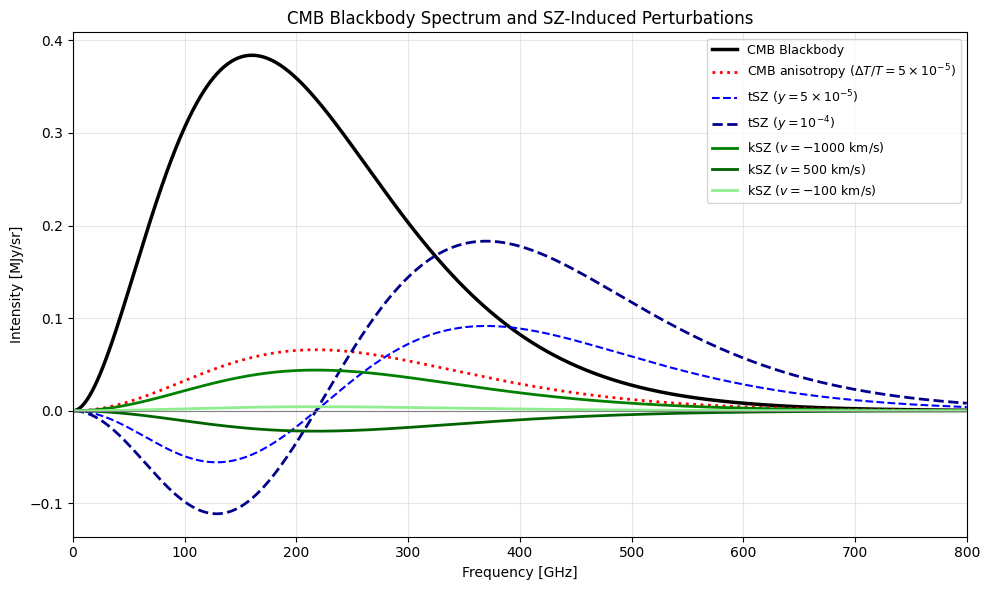

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Physical constants (SI units)
h = 6.62607015e-34
kB = 1.380649e-23
c = 2.99792458e8
T_CMB = 2.7255

# Frequency grid
nu_ghz = np.linspace(1.0, 800.0, 3000)   # in GHz
nu = nu_ghz * 1e9                        # convert to Hz
x = h * nu / (kB * T_CMB)

# Planck function (absolute CMB blackbody)
def planck(nu, T):
    return (2*h*nu**3 / c**2) / (np.exp(h*nu/(kB*T)) - 1)

# Convert intensity to MJy/sr
def to_MJy_sr(I_SI):
    jy = I_SI / 1e-26      # Jy/sr
    return jy / 1e6        # MJy/sr

# Compute the CMB spectrum
I_CMB = to_MJy_sr(planck(nu, T_CMB))

# SZ spectral functions
def g_tsz(x):
    ex = np.exp(x)
    return x**4 * ex / (ex - 1)**2 * (x*(ex + 1)/(ex - 1) - 4)

def h_ksz(x):
    ex = np.exp(x)
    return x**4 * ex / (ex - 1)**2

# I0 prefactor in MJy/sr
I0 = 2*(kB*T_CMB)**3 / (h**2 * c**2)
I0 = to_MJy_sr(I0)  # convert

# tSZ parameters
y_vals = [5e-5, 1e-4]
deltaI_tsz = [I0 * y * g_tsz(x) for y in y_vals]

# kSZ parameters
tau_e = 1e-2
v_vals = np.array([-1000, 500, -100]) * 1e3
beta_vals = v_vals / c
deltaI_ksz = [-I0 * tau_e * b * h_ksz(x) for b in beta_vals]

# Primary CMB anisotropy (ΔT/T)
deltaT_over_T = 5e-5
deltaI_cmb = I0 * deltaT_over_T * h_ksz(x)

# -------------------------------------------------------------------------
# Plot: absolute CMB + perturbations
# -------------------------------------------------------------------------
plt.figure(figsize=(10, 6))

# Absolute CMB
plt.plot(nu_ghz, I_CMB * 10e-4, color="k", linewidth=2.5, label="CMB Blackbody")

# CMB anisotropy
plt.plot(nu_ghz, deltaI_cmb, linestyle=":", color="red", linewidth=2,
         label=r"CMB anisotropy ($\Delta T/T = 5\times 10^{-5}$)")

# tSZ
plt.plot(nu_ghz, deltaI_tsz[0], linestyle="--", color="blue", linewidth=1.5,
         label=r"tSZ ($y = 5\times 10^{-5}$)")
plt.plot(nu_ghz, deltaI_tsz[1], linestyle="--", color="darkblue", linewidth=2,
         label=r"tSZ ($y = 10^{-4}$)")

# kSZ
colors = ["green", "darkgreen", "lightgreen"]
labels = [r"kSZ ($v = -1000$ km/s)",
          r"kSZ ($v = 500$ km/s)",
          r"kSZ ($v = -100$ km/s)"]
for di, col, lab in zip(deltaI_ksz, colors, labels):
    plt.plot(nu_ghz, di, color=col, linewidth=2, label=lab)

# Formatting
plt.axhline(0, color="gray", linewidth=0.8)
plt.xlim(0, 800)
# plt.ylim(-0.2, np.max(I_CMB)*1.05)

plt.xlabel("Frequency [GHz]")
plt.ylabel(r"Intensity [MJy/sr]")
plt.title("CMB Blackbody Spectrum and SZ-Induced Perturbations")

plt.grid(alpha=0.3)
plt.legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()
